In [15]:
import sys
import astropy.units as u
import pickle


sys.path.append(
    "/cosma8/data/dp004/dc-gilf1/projects/MG_project/ELG-halo-connection/src"
)

from elg_halo_connection.data_processor import DataProcessor
from elg_halo_connection.tauv_calibration import DustAttenuationCalibrator

## 1. Calibration setup

The calibration is performed using the GR simulation at snapshot 19,
corresponding to approximately $z=0.1$. The GSWLC catalogue provides
the observational comparison sample.

In [37]:
# Main simulation for analysis
simName = 'GR'
snapNum = 8
simPath = f'/cosma8/data/dp203/bl267/Data/ClusterSims/L302_N1136_{simName}/'
pickle_dir = '/cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/'
simInfo = [(simName, snapNum, simPath)]
minStellpart = 100

processor = DataProcessor(
    simInfo=simInfo,
    pickle_dir=pickle_dir,
    minStellPart=minStellPart,
    save_data=True,
    overwrite=False
)

# Aperture dictionary for all subhalos in simulation GR snapshot 8
apDict_GR_snap8 = processor.compute_all_apertures(
                simName=simName,
                snapNum=snapNum,
                R=30*u.kpc,
                ncpu=10,
                save_data = True,
                overwrite = False
            )


Aperture dictionary already exists for GR at snapshot 8!
Loading aperture dictionary from /cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/apDict_GR_snap8...
Successfully loaded aperture dictionary!


In [38]:
# Calibration sim
simName_cal = 'GR'
snapNum_cal = 19
simPath_cal = f'/cosma8/data/dp203/bl267/Data/ClusterSims/L302_N1136_{simName_cal}/'
simInfo_cal = [(simName_cal, snapNum_cal, simPath_cal)]

processor_cal = DataProcessor(simInfo = simInfo_cal, pickle_dir = pickle_dir, minStellPart = minStellPart, save_data = True, overwrite = False)

_, cal_subDict, cal_simDict, _ = processor_cal.load_data()
cal_subDict = cal_subDict[simName_cal][snapNum_cal]
cal_simDict = cal_simDict[simName_cal][snapNum_cal]

Opening saved data for GR, snapshot 19...
Finished loading data


## 2. Run calibration

In [39]:
# Galaxy catalogue for calibration
with open('/cosma8/data/dp004/dc-gilf1/projects/MG_project/pickle/GSWLC_catalogue', 'rb') as handle:
    df_GSWLC = pickle.load(handle)

# Set up dust attenuation calibration using GR snapshot 19
# and apply the calibrated model to GR snapshot 8 aperture data
GR_snap8_dustcalibrator = DustAttenuationCalibrator(cal_simDict, cal_subDict, df_GSWLC, minStellPart = minStellPart)

# Dictionary
alpha = -0.6
calibration_res_GR = GR_snap8_dustcalibrator.run_calibration(apDict = apDict_GR_snap8, alpha = alpha)
print(calibration_res_GR.keys())

Successfully assigned V-band optical depths to aperture dictionary!
dict_keys(['Optimal_Params', 'GSWLC', 'Aperture_Snapshot', 'Calibration_Snapshot'])


## 3. Compare $\tau_V$ distributions

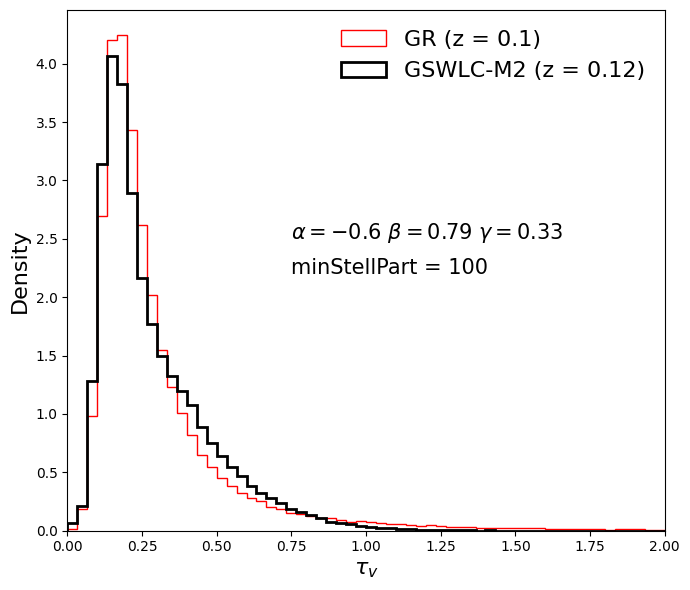

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Extract from calibration dictionary
df_GSWLC   = calibration_res_GR['GSWLC']['df']
GSWLC_tauV = calibration_res_GR['GSWLC']['tauV']
optBeta, optGamma = calibration_res_GR['Optimal_Params']['Beta'], calibration_res_GR['Optimal_Params']['Gamma']
cal_tauV = calibration_res_GR['Calibration_Snapshot']['tauV']
cal_redshift = calibration_res_GR['Calibration_Snapshot']['Redshift']

# Define common binning parameters
bin_min = 0
bin_max = 2
num_bins = 60

# Create an array of bin edges
bins = np.linspace(bin_min, bin_max, num_bins + 1)

redSim   = round(cal_redshift, 2)
redGSWLC = round(np.mean(df_GSWLC['Redshift']), 2)

fig, ax = plt.subplots(1, 1, figsize = (7, 6))

ax.hist(cal_tauV, bins = bins, density = True, histtype = 'step', color = 'red', label = f'GR (z = {redSim})')
ax.hist(GSWLC_tauV, bins = bins, density = True, histtype = 'step', color = 'black', label = f'GSWLC-M2 (z = {redGSWLC})', linewidth = 2)

ax.set_xlim(bin_min, bin_max)

axisFontsize = 16
ax.set_xlabel(r'$\tau_v$', fontsize=axisFontsize)
ax.set_ylabel('Density', fontsize=axisFontsize)

textFontsize   = 15
textPos    = [0.75, 2.5]
textPosTNG = [0.65, 2.2] 
ax.text(textPos[0], textPos[1], rf'$\alpha = {alpha} \ \beta = {round(optBeta, 2)} \ \gamma = {round(optGamma, 2)}$', fontsize = textFontsize)
ax.text(0.75, 2.2, f'minStellPart = {minStellPart}', fontsize = textFontsize)

ax.legend(frameon = False, fontsize = 16)

plt.tight_layout()

plt.show()

# Dust Attenuation Calibration

This notebook demonstrates the calibration of the V-band optical depth
$\tau_V$ used in the galaxy SED model.

The calibration compares the simulated $\tau_V$ distribution with the
observed distribution from the GSWLC catalogue and determines the
parameters $\beta$ and $\gamma$ in the dust attenuation model.

The calibrated parameters are then applied to the aperture data used by
the galaxy SED model.